In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import tqdm
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from attention_classifier import AttentionClassifier
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle

features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd

path_3b = Path("../events/MG3/dataframes/threeTag_picoAOD.h5")
path_4b = Path("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
path_signal = Path("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b = pd.read_hdf(path_3b)
df_bg4b = pd.read_hdf(path_4b)
df_signal = pd.read_hdf(path_signal)
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]
loaded_df = {path_3b: df_3b, path_4b: df_bg4b, path_signal: df_signal}

signal_ratio 0.0 SR_CR_size 0.05 0.95


  0%|          | 0/3 [00:00<?, ?it/s]

Calibrator: platt


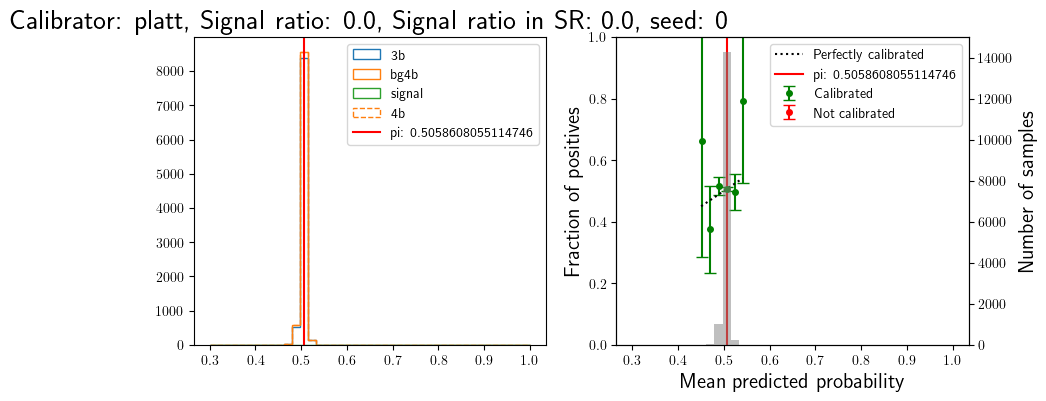

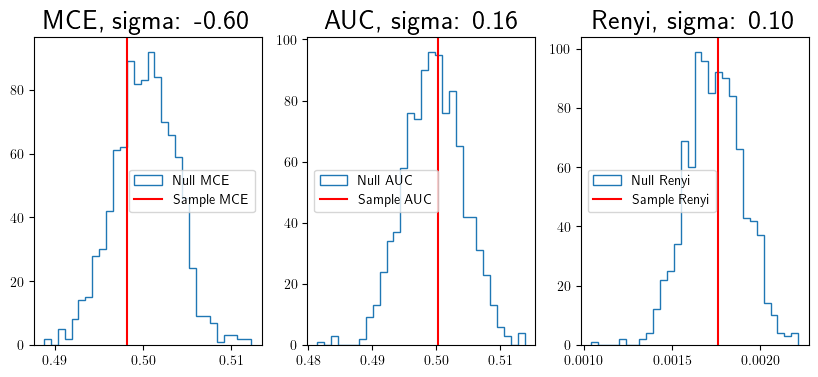

pi: 0.5058607459068298
pi test: 0.506165623664856
p_value MCE: 0.269
p_value AUC: 0.435
p_value Renyi: 0.459
sigma MCE: -0.5982065125983996
sigma AUC: 0.1552848219871521
sigma Renyi: 0.10436750293935391
Calibrator: minimize_renyi
-0.004666350781917572
0.012320604269709712 [1.69869387e-02 5.87821006e-12]


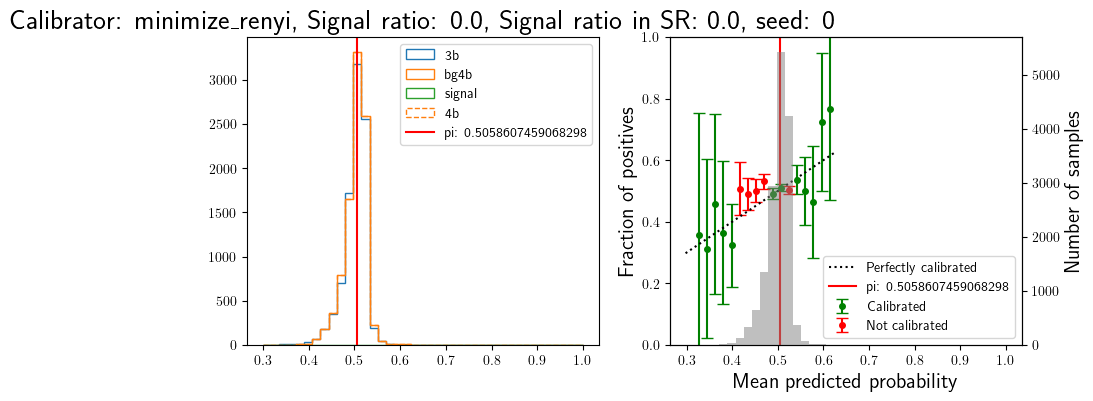

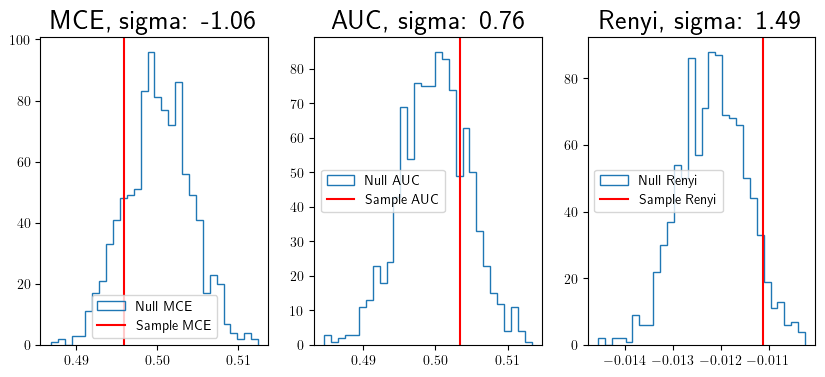

 33%|███▎      | 1/3 [00:08<00:16,  8.39s/it]

pi: 0.5058607459068298
pi test: 0.506165623664856
p_value MCE: 0.158
p_value AUC: 0.236
p_value Renyi: 0.064
sigma MCE: -1.0552282739476575
sigma AUC: 0.759794294834137
sigma Renyi: 1.4900858163674924
Calibrator: platt


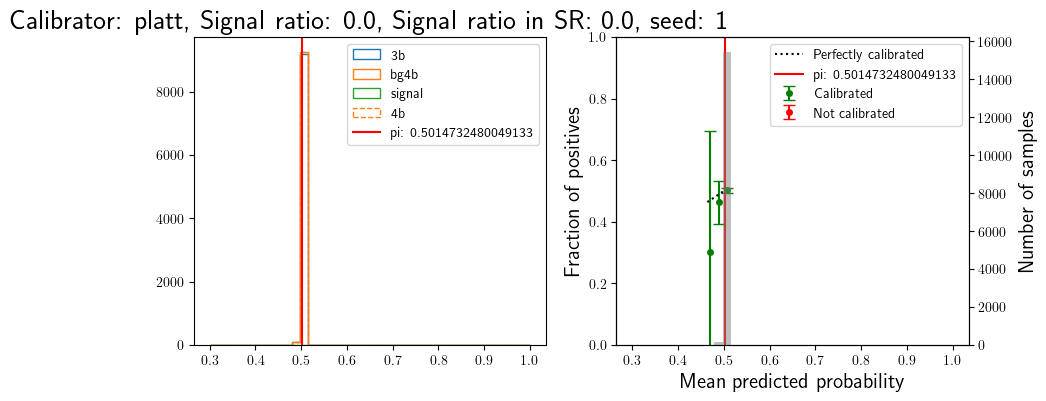

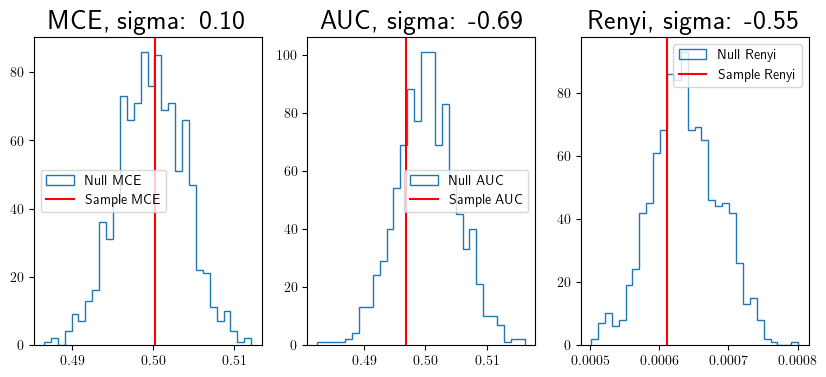

pi: 0.5014732480049133
pi test: 0.5016913414001465
p_value MCE: 0.537
p_value AUC: 0.76
p_value Renyi: 0.711
sigma MCE: 0.09701975597382237
sigma AUC: -0.6909356117248535
sigma Renyi: -0.5490088964735531
Calibrator: minimize_renyi
0.008303523994982243
0.023054137124003837 [1.47506718e-02 4.84687085e-12]


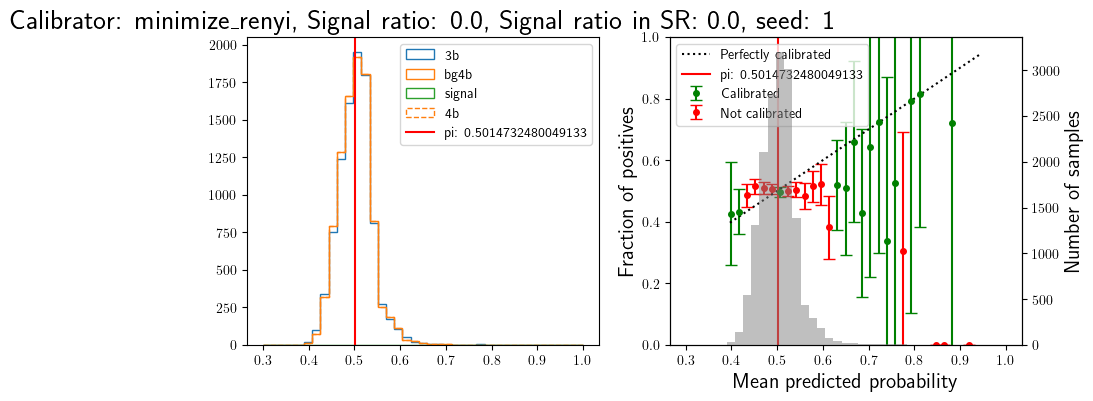

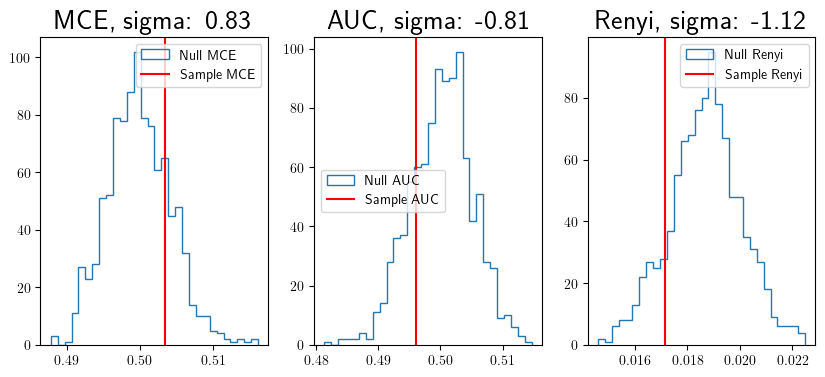

 67%|██████▋   | 2/3 [00:13<00:06,  6.68s/it]

pi: 0.5014732480049133
pi test: 0.5016913414001465
p_value MCE: 0.789
p_value AUC: 0.789
p_value Renyi: 0.863
sigma MCE: 0.8308131253745635
sigma AUC: -0.8126120567321777
sigma Renyi: -1.1167378466196014
Calibrator: platt


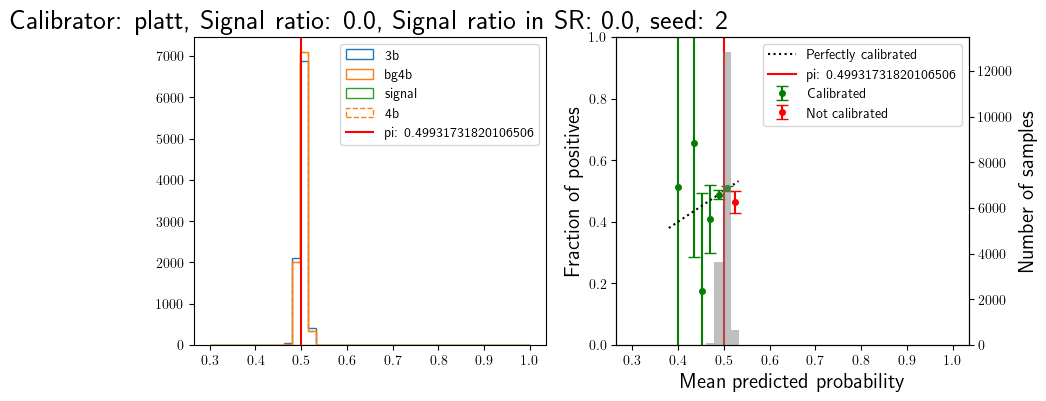

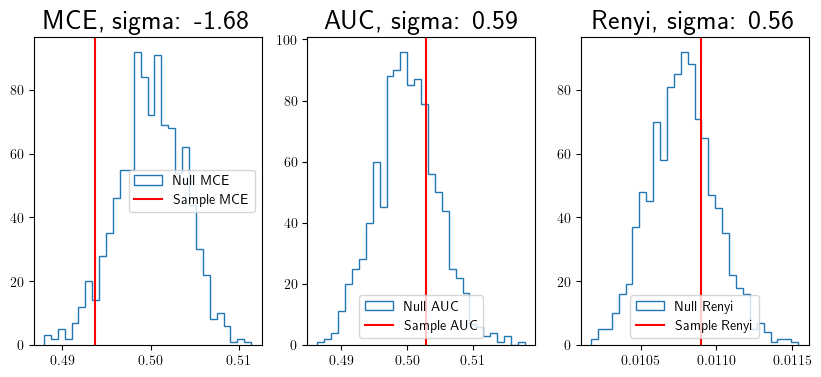

pi: 0.49931731820106506
pi test: 0.5018327832221985
p_value MCE: 0.055
p_value AUC: 0.265
p_value Renyi: 0.276
sigma MCE: -1.6825982694271644
sigma AUC: 0.5854954719543457
sigma Renyi: 0.5561513031624344
Calibrator: minimize_renyi
0.01600443385541439
0.01875022895345957 [2.74584888e-03 3.40420417e-12]


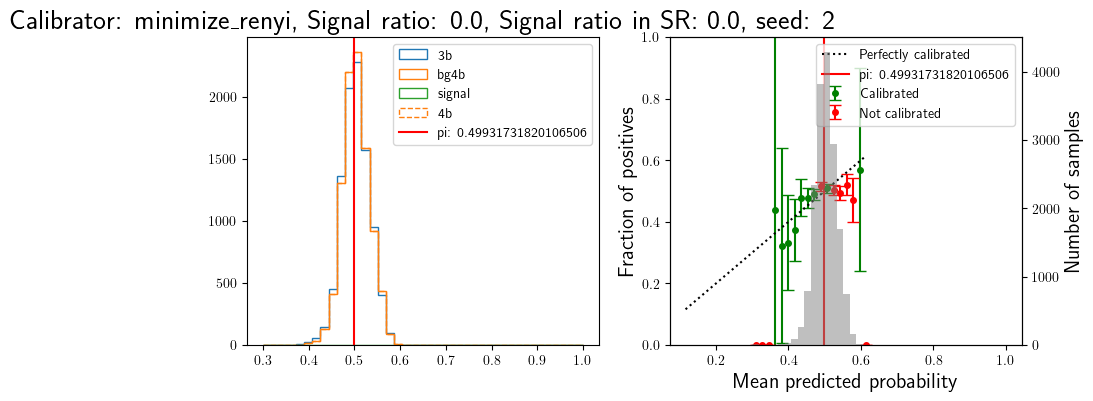

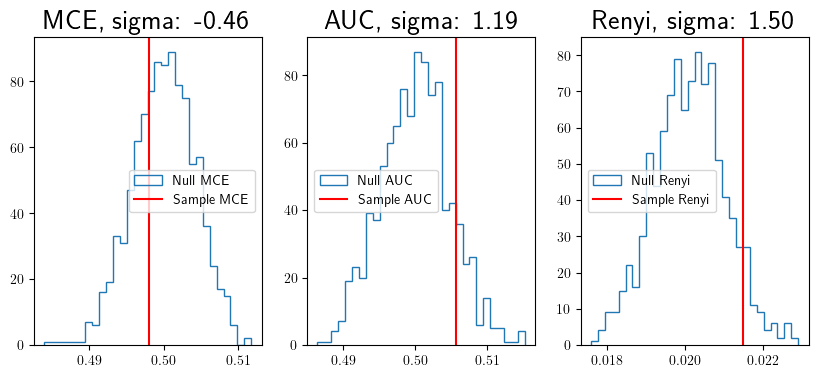

100%|██████████| 3/3 [00:20<00:00,  6.89s/it]


pi: 0.49931731820106506
pi test: 0.5018327832221985
p_value MCE: 0.317
p_value AUC: 0.118
p_value Renyi: 0.068
sigma MCE: -0.4606911775660886
sigma AUC: 1.1902034282684326
sigma Renyi: 1.4997362118070616
signal_ratio 0.01 SR_CR_size 0.05 0.95


  0%|          | 0/3 [00:00<?, ?it/s]

Calibrator: platt


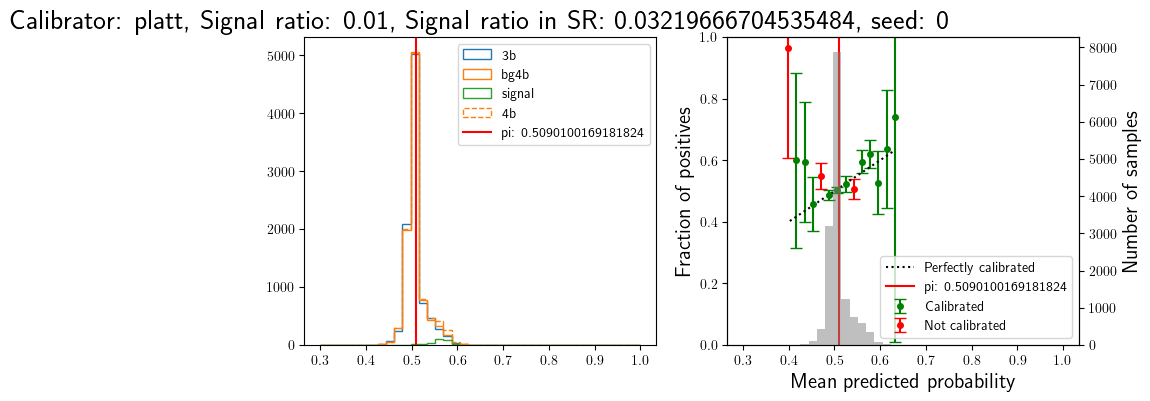

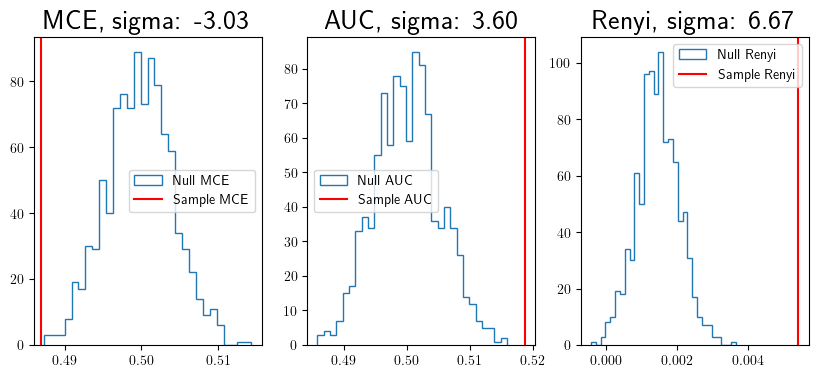

pi: 0.5090100169181824
pi test: 0.5082724690437317
p_value MCE: 0.0
p_value AUC: 0.0
p_value Renyi: 0.0
sigma MCE: -3.0265821697611712
sigma AUC: 3.5962748527526855
sigma Renyi: 6.674391080926554
Calibrator: minimize_renyi
0.025333553552627563
0.05141136104722044 [2.60778663e-02 1.27761278e-12]


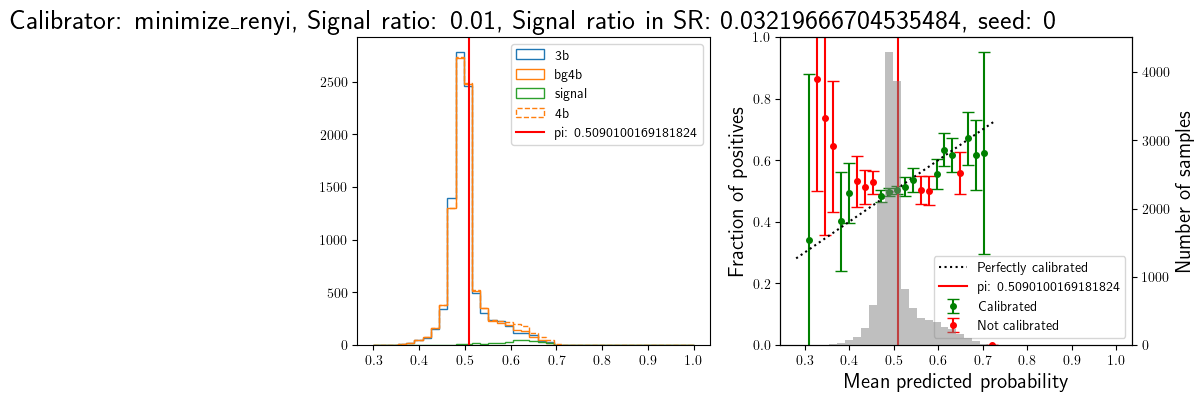

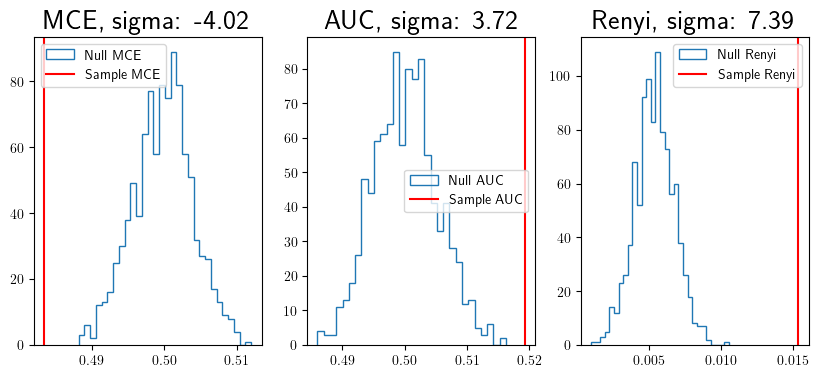

 33%|███▎      | 1/3 [00:05<00:11,  5.60s/it]

pi: 0.5090100169181824
pi test: 0.5082724690437317
p_value MCE: 0.0
p_value AUC: 0.0
p_value Renyi: 0.0
sigma MCE: -4.018487957381587
sigma AUC: 3.7211267948150635
sigma Renyi: 7.385877257033804
Calibrator: platt


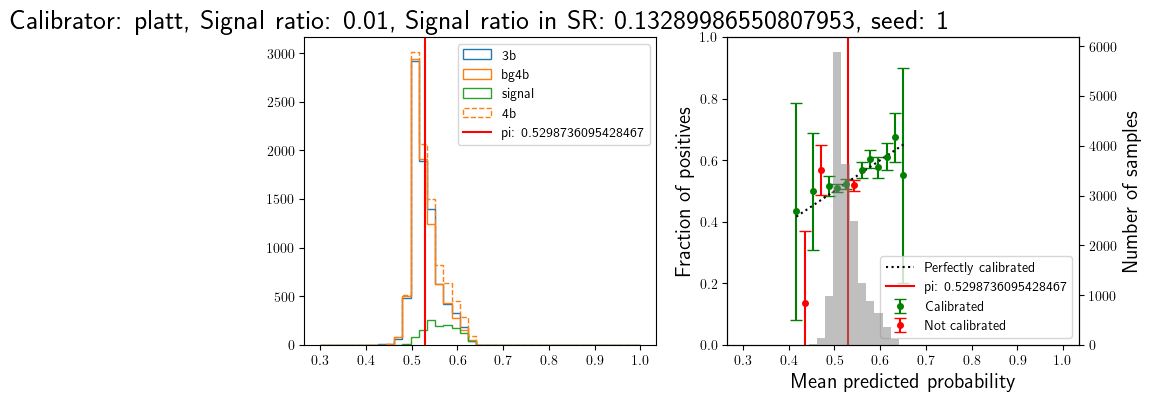

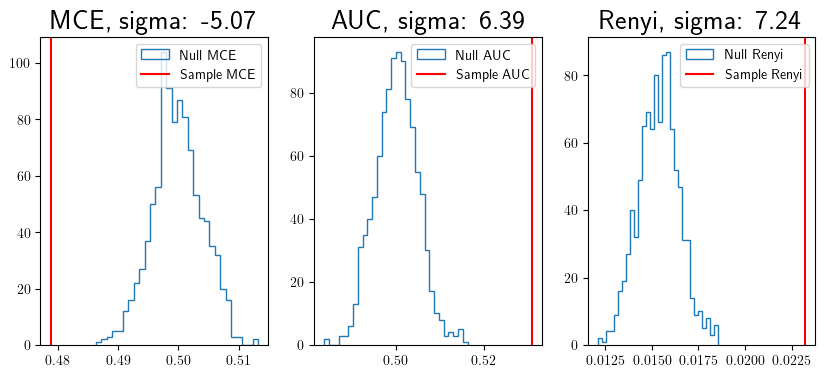

pi: 0.5298736095428467
pi test: 0.5313628911972046
p_value MCE: 0.0
p_value AUC: 0.0
p_value Renyi: 0.0
sigma MCE: -5.065103296841961
sigma AUC: 6.390614032745361
sigma Renyi: 7.239728451873406
Calibrator: minimize_renyi


/home/export/soheuny/.conda/envs/coffea_torch/lib/python3.11/site-packages/cvxpy/problems/problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


0.05937890708446503
0.09159253646810317 [3.22138155e-02 1.22767244e-09]


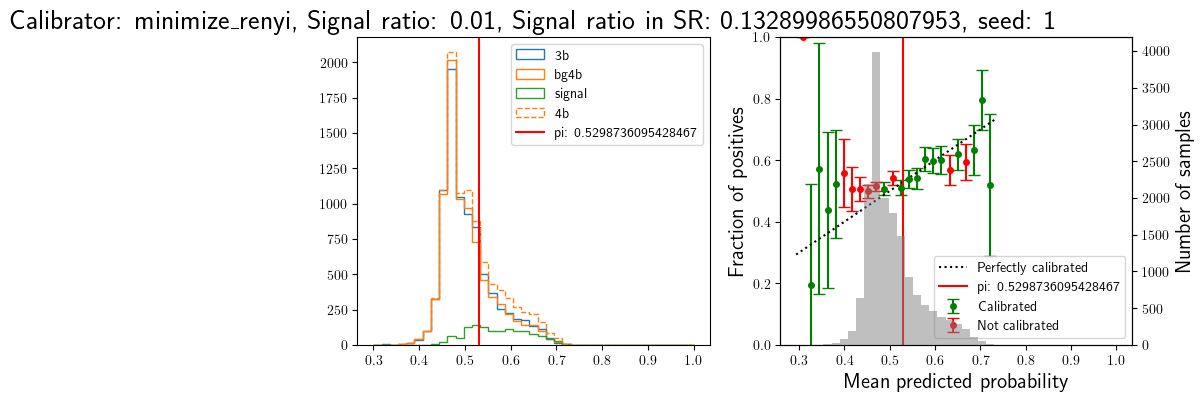

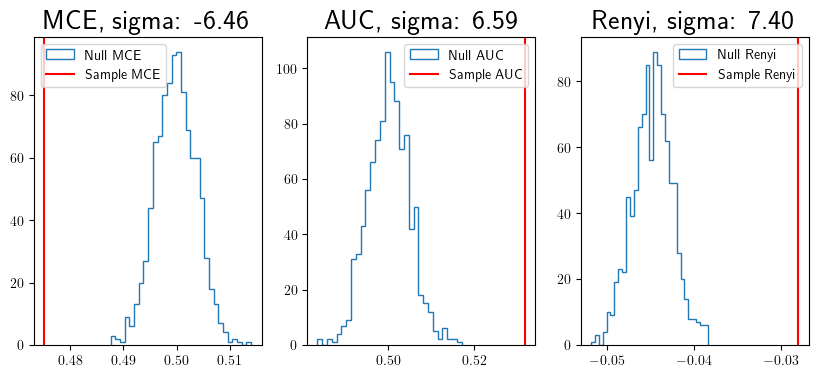

 67%|██████▋   | 2/3 [00:11<00:05,  5.85s/it]

pi: 0.5298736095428467
pi test: 0.5313628911972046
p_value MCE: 0.0
p_value AUC: 0.0
p_value Renyi: 0.0
sigma MCE: -6.45809297450671
sigma AUC: 6.585078716278076
sigma Renyi: 7.399772745016331
Calibrator: platt


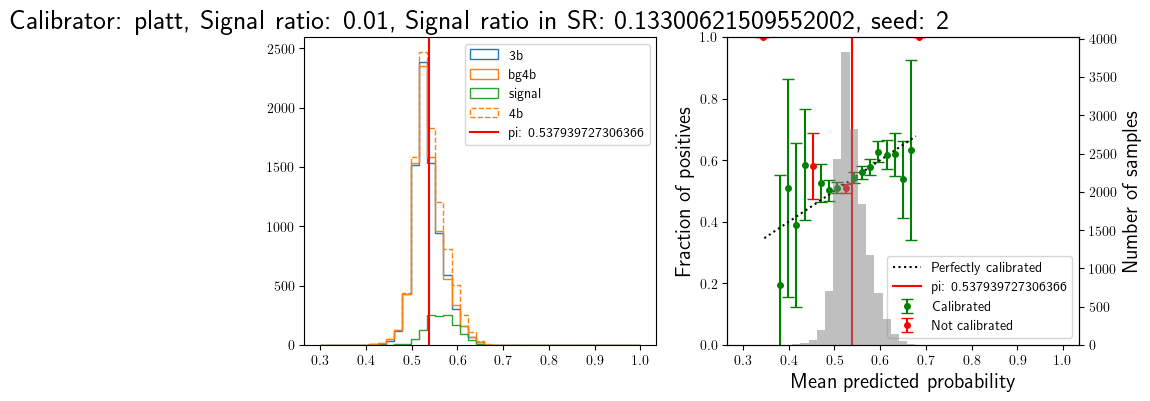

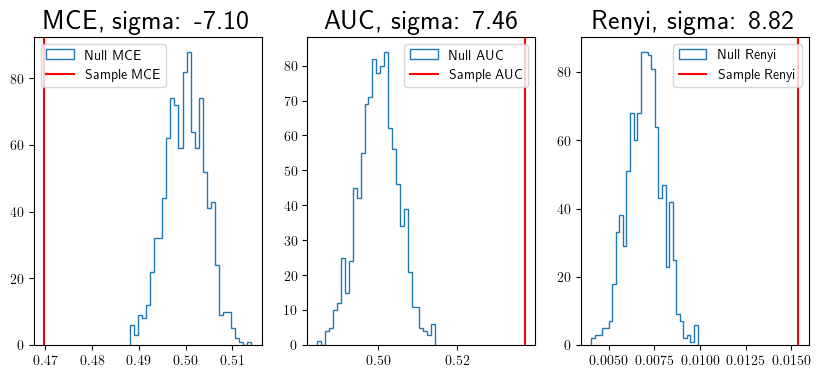

pi: 0.537939727306366
pi test: 0.5371696949005127
p_value MCE: 0.0
p_value AUC: 0.0
p_value Renyi: 0.0
sigma MCE: -7.0974045533661085
sigma AUC: 7.46051025390625
sigma Renyi: 8.824629296090313
Calibrator: minimize_renyi
0.04032951220870018
0.10152427702347033 [6.11948037e-02 1.31990195e-12]


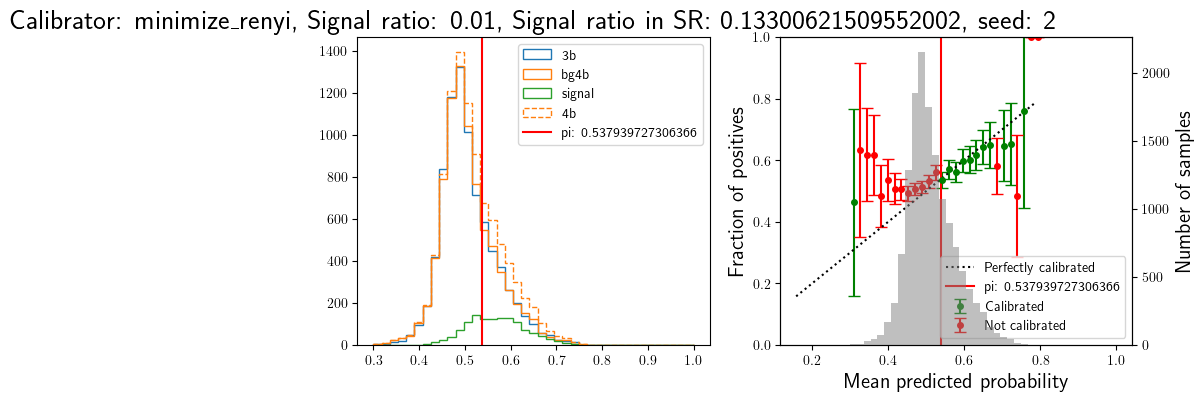

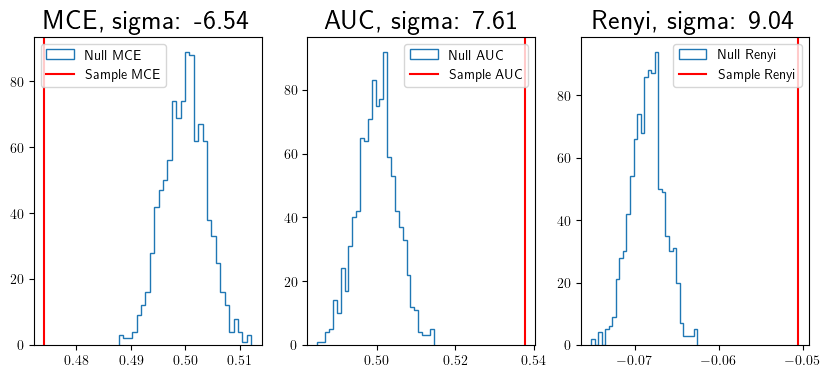

100%|██████████| 3/3 [00:17<00:00,  5.69s/it]


pi: 0.537939727306366
pi test: 0.5371696949005127
p_value MCE: 0.0
p_value AUC: 0.0
p_value Renyi: 0.0
sigma MCE: -6.542624078799053
sigma AUC: 7.609588146209717
sigma Renyi: 9.042278554203945
signal_ratio 0.02 SR_CR_size 0.05 0.95


  0%|          | 0/3 [00:00<?, ?it/s]

Calibrator: platt


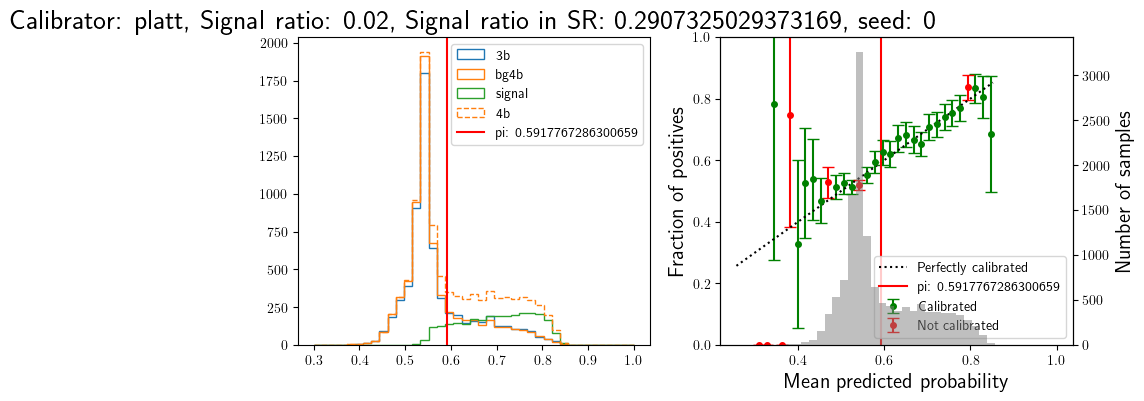

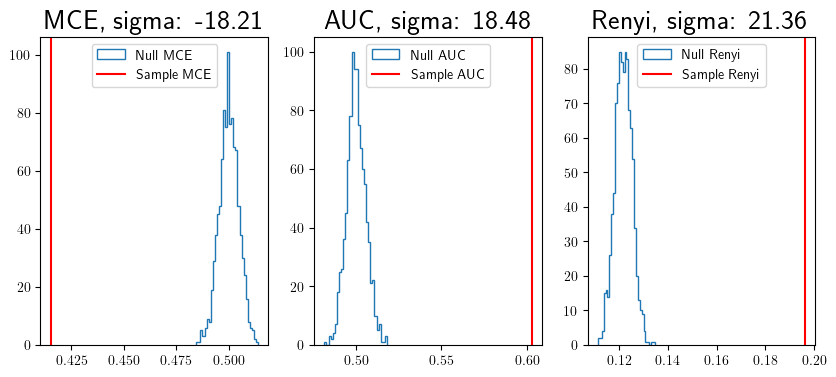

pi: 0.5917767286300659
pi test: 0.5925683379173279
p_value MCE: 0.0
p_value AUC: 0.0
p_value Renyi: 0.0
sigma MCE: -18.208484090397796
sigma AUC: 18.475236892700195
sigma Renyi: 21.356061219779722
Calibrator: minimize_renyi


/home/export/soheuny/.conda/envs/coffea_torch/lib/python3.11/site-packages/cvxpy/problems/problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


0.3491242527961731
0.5342037427486934 [1.85079427e-01 1.53877039e-10]


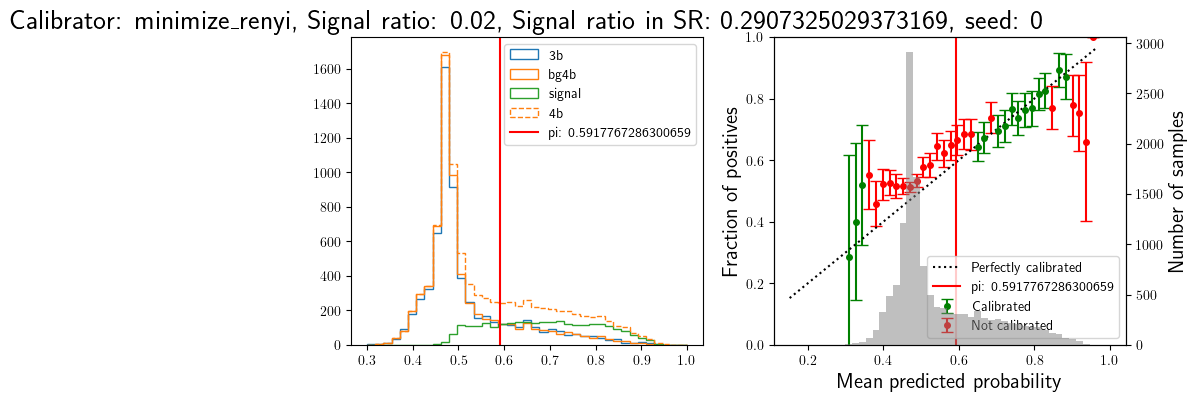

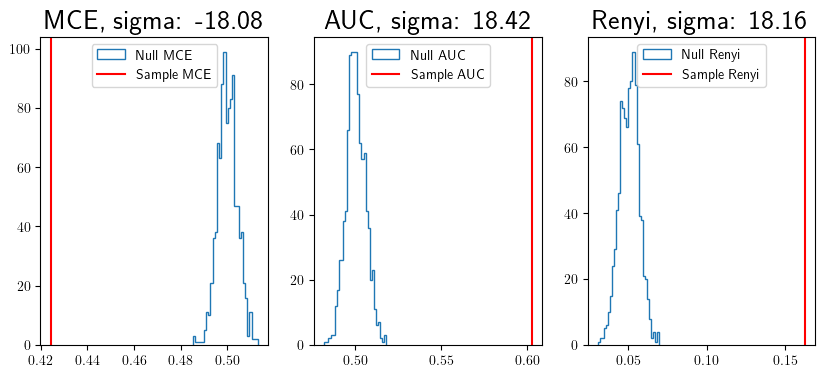

 33%|███▎      | 1/3 [00:05<00:11,  5.85s/it]

pi: 0.5917767286300659
pi test: 0.5925683379173279
p_value MCE: 0.0
p_value AUC: 0.0
p_value Renyi: 0.0
sigma MCE: -18.081663158374734
sigma AUC: 18.416027069091797
sigma Renyi: 18.15662976851108
Calibrator: platt


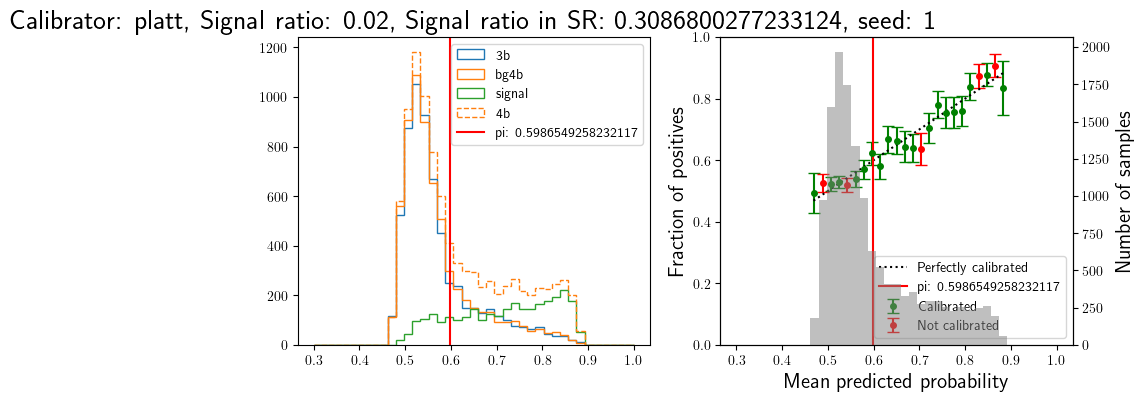

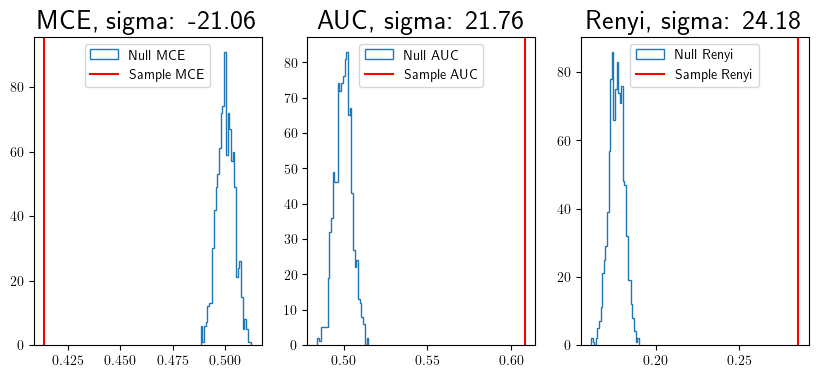

pi: 0.5986549854278564
pi test: 0.597666323184967
p_value MCE: 0.0
p_value AUC: 0.0
p_value Renyi: 0.0
sigma MCE: -21.06412738282129
sigma AUC: 21.75895881652832
sigma Renyi: 24.175391544150564
Calibrator: minimize_renyi
0.46638724207878113
0.6612541406718826 [1.94866952e-01 1.30903558e-14]


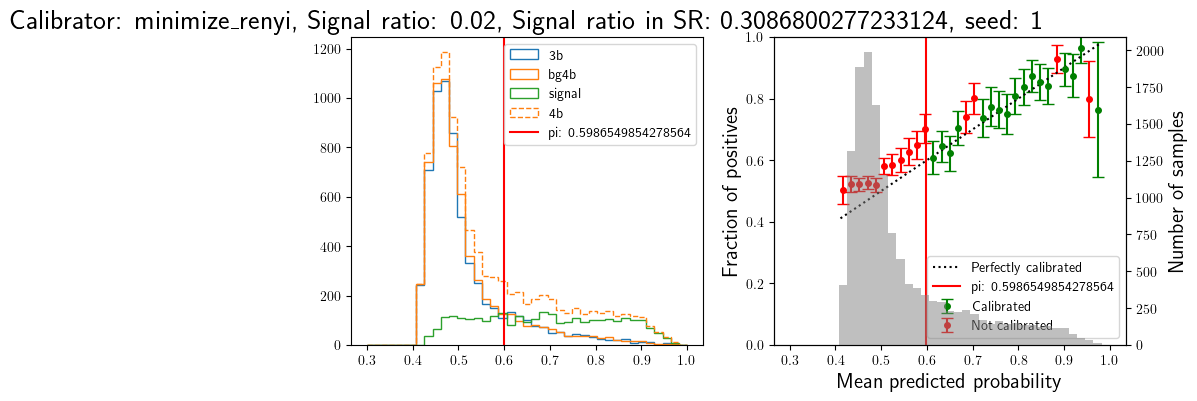

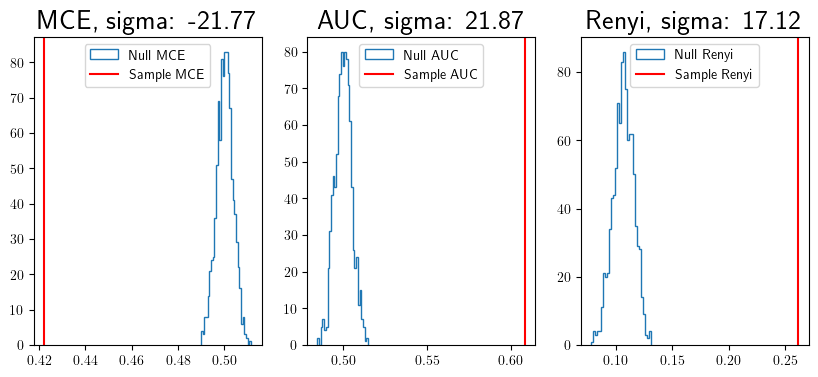

 67%|██████▋   | 2/3 [00:11<00:05,  5.73s/it]

pi: 0.5986549854278564
pi test: 0.597666323184967
p_value MCE: 0.0
p_value AUC: 0.0
p_value Renyi: 0.0
sigma MCE: -21.769337779686442
sigma AUC: 21.874004364013672
sigma Renyi: 17.11903592632345
Calibrator: platt


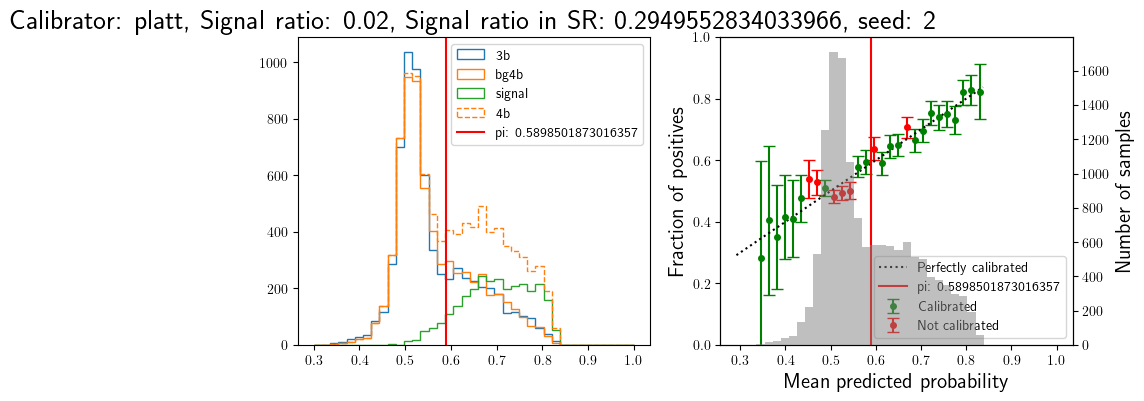

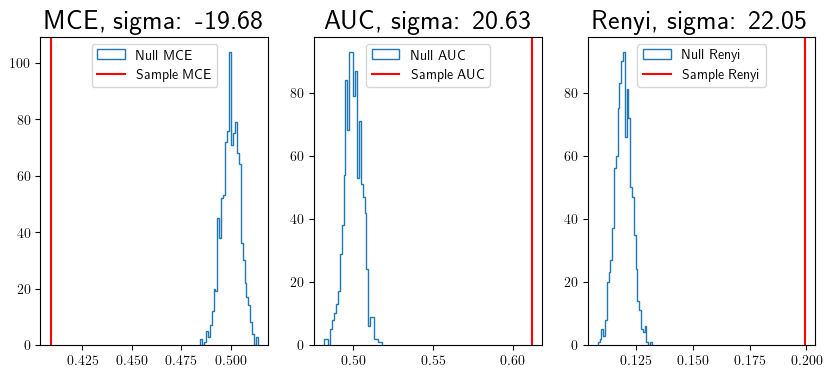

pi: 0.5898501873016357
pi test: 0.5883869528770447
p_value MCE: 0.0
p_value AUC: 0.0
p_value Renyi: 0.0
sigma MCE: -19.679780545860385
sigma AUC: 20.628963470458984
sigma Renyi: 22.047340328415157
Calibrator: minimize_renyi
0.4092547297477722
0.6118987165558645 [2.02644000e-01 1.79438837e-13]


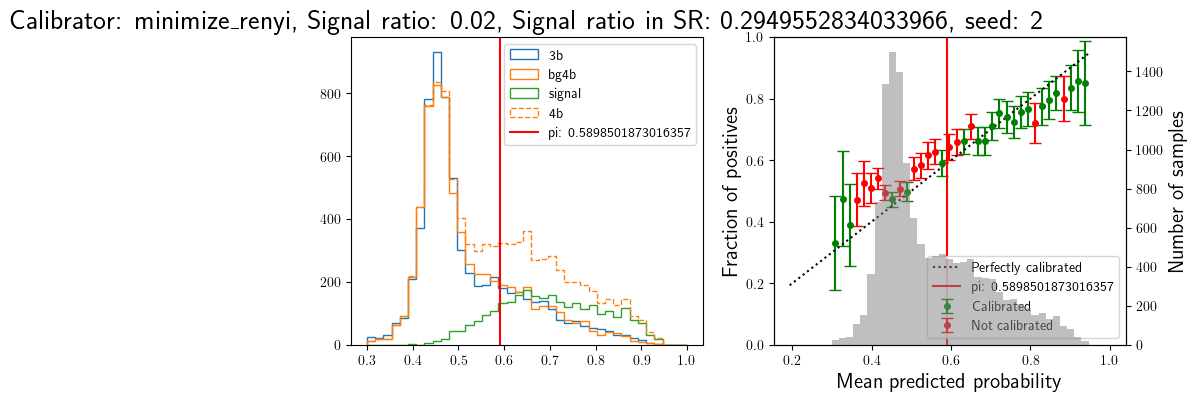

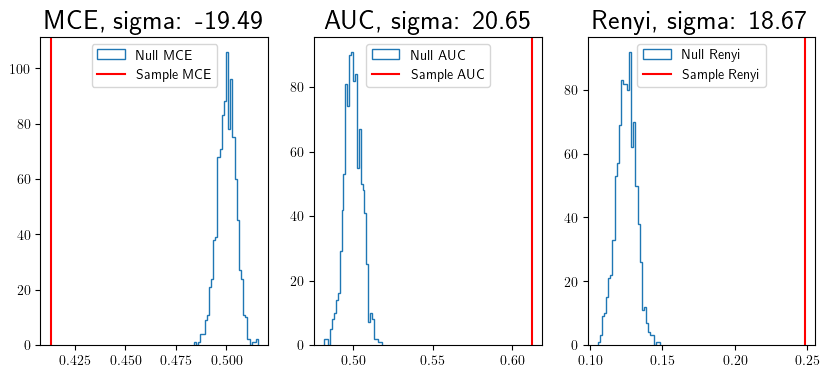

100%|██████████| 3/3 [00:17<00:00,  5.68s/it]

pi: 0.5898501873016357
pi test: 0.5883869528770447
p_value MCE: 0.0
p_value AUC: 0.0
p_value Renyi: 0.0
sigma MCE: -19.488875789152956
sigma AUC: 20.65389060974121
sigma Renyi: 18.67081236826489


In [3]:
from plots import calibration_plot
from signal_region import get_SR_CR_cut, compute_sr_stats
from events_data import get_is_signal
from utils import select_random_true_elements
from mi_test import mi_test, calibrate_fvt_scores_cv

n_3b = 100_0000
ratio_4b = 0.5
signal_filename = "HH4b_picoAOD.h5"
experiment_name = "CR_fvt_training_ensemble_max_smeared"
N_REPS = 1000
tst_seed = 42

SR_CR_sizes = [
    (0.05, 0.95), 
    # (0.1, 0.9),
    # (0.15, 0.85),
    # (0.2, 0.8),
               ]
renyi_alpha = 2

calib_bins = np.linspace(0.3, 1.0, 40)  
for SR_size, CR_size in SR_CR_sizes:
    for signal_ratio in [0.0, 0.01, 0.02]:
            print("signal_ratio", signal_ratio, "SR_CR_size", SR_size, CR_size)
            hparams_filter = {
                "experiment_name": experiment_name,
                "aux_info_step": 3,
                "dataset": lambda x: (
                    x["n_3b"] == n_3b
                    and x["ratio_4b"] == ratio_4b
                    and x["signal_filename"] == signal_filename
                    and x["signal_ratio"] == signal_ratio
                    and x["seed"] <= 2
                ),
                "signal_region": lambda x: (
                    x["4b_in_SR"] == SR_size and x["4b_in_CR"] == CR_size
                ),
            }
            CR_fvt_hashes = TrainingInfo.find(hparams_filter)
            # sort by seed
            CR_fvt_hashes = sorted(CR_fvt_hashes, key=lambda x: TrainingInfo.load(x).hparams["dataset"]["seed"])
            
            for CR_fvt_hash in tqdm.tqdm(CR_fvt_hashes):
                hparams_filter = {"CR_fvt_hash": CR_fvt_hash, "dataloader": lambda x: x["batch_size"] == 256}
                mi_test_hash = TrainingInfo.find(hparams_filter)
                if not len(mi_test_hash) == 1:
                    for h in mi_test_hash:
                        print(TrainingInfo.load(h).hparams)
                    raise ValueError("len(mi_test_hash) != 1")
                mi_test_hash = mi_test_hash[0]
                mi_test_tinfo = TrainingInfo.load(mi_test_hash)
                CR_fvt_tinfo = TrainingInfo.load(CR_fvt_hash)
                SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
                ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
                stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
                signal_filename = CR_fvt_tinfo.hparams["dataset"]["signal_filename"]

                ms_idx = TrainingInfo.load(SR_stats_hashes[0]).ms_idx
                msamples = MotherSamples.load(CR_fvt_tinfo.ms_hash)
                train_scdinfo = msamples.scdinfo[ms_idx]
                tst_scdinfo = msamples.scdinfo[~ms_idx]

                df_train = train_scdinfo.fetch_data(loaded_df)
                df_train["signal"] = get_is_signal(train_scdinfo, signal_filename)
                events_train = EventsData.from_dataframe(df_train, features)

                df_tst = tst_scdinfo.fetch_data(loaded_df)
                df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
                events_tst = EventsData.from_dataframe(df_tst, features)

                SR_stats_train, SR_stats_tst = compute_sr_stats(
                    SR_stats_hashes,
                    signal_filename,
                    ensemble_mode,
                    stats_type,
                    loaded_df,
                )
                
                SR_cut, _ = get_SR_CR_cut(
                    SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
                )
                SR_idx = SR_stats_tst >= SR_cut
                
                SR_3b_idx = events_tst.is_3b & SR_idx
                SR_4b_idx = events_tst.is_4b & SR_idx
                
                mi_test_test_ratio = mi_test_tinfo.hparams["mi_test_dataset"]["test_ratio"]
                mi_test_data_seed = mi_test_tinfo.hparams["mi_test_dataset"]["data_seed"]

                # select test_ratio of the events in the SR for 3b and 4b
                SR_3b_test_idx = select_random_true_elements(
                    SR_3b_idx,
                    mi_test_test_ratio,
                    mi_test_data_seed,
                )
                SR_4b_test_idx = select_random_true_elements(
                    SR_4b_idx,
                    mi_test_test_ratio,
                    mi_test_data_seed,
                )
                
            

                SR_test_idx = SR_3b_test_idx | SR_4b_test_idx
                events_tst_SR_test = events_tst[SR_test_idx]
                events_tst_SR_train = events_tst[SR_idx & ~SR_test_idx]
                fvt_scores_tst_SR_test = mi_test_tinfo.aux_info["fvt_scores_tst_SR_test"]
                reweights_tst_SR_test = mi_test_tinfo.aux_info["reweights_tst_SR_test"]
                reweights_tst_SR_train = mi_test_tinfo.aux_info["reweights_tst_SR_train"]
                
                # calibrate the fvt scores
                
                
                SR_test_idx = SR_3b_test_idx | SR_4b_test_idx
                SR_test_idx_in_SR_tst = SR_test_idx[SR_idx]
                
                tst_idx = np.zeros_like(SR_3b_test_idx, dtype=int)
                tst_idx[SR_3b_test_idx] = 1
                tst_idx[SR_4b_test_idx] = 2
                tst_idx = tst_idx[tst_idx != 0]
                SR_3b_test_idx = tst_idx == 1
                SR_4b_test_idx = tst_idx == 2
                
                CR_fvt_scores_tst_SR_test = (CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"])[SR_test_idx_in_SR_tst]
                CR_reweights_tst_SR_test = np.where(
                    events_tst_SR_test.is_4b,
                    1,
                    CR_fvt_scores_tst_SR_test / (1 - CR_fvt_scores_tst_SR_test))
                events_tst_SR_test_clone = events_tst_SR_test.clone()
                events_tst_SR_test_clone.reweight(CR_reweights_tst_SR_test * events_tst_SR_test.weights)
                
                weights_test = events_tst_SR_test.weights * reweights_tst_SR_test
                weights_train = events_tst_SR_train.weights * reweights_tst_SR_train
                
                pi = np.sum(weights_train[events_tst_SR_train.is_4b]) / np.sum(weights_train)
                
                for calibrator in ["platt", "minimize_renyi"]:
                    print(f"Calibrator: {calibrator}")
                    fvt_scores_tst_SR_test_calib = calibrate_fvt_scores_cv(fvt_scores_tst_SR_test, 
                                                                events_tst_SR_test.is_4b, 
                                                                weights_test,
                                                                calibrator=calibrator, 
                                                                renyi_alpha=renyi_alpha,
                                                                pi=pi)
                    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
                    hist_events_by_labels(events_tst_SR_test_clone, fvt_scores_tst_SR_test_calib, bins=calib_bins, ax=ax[0])
                    ax[0].hist(fvt_scores_tst_SR_test_calib[events_tst_SR_test.is_4b], 
                            weights=events_tst_SR_test_clone.weights[events_tst_SR_test.is_4b], 
                            bins=calib_bins, label="4b", histtype="step", linestyle="--", color=plt.get_cmap("tab10").colors[1])
                    ax[0].axvline(pi, color="red", label=f"pi: {pi}")
                    ax[0].set_title(f"Calibrator: {calibrator}, Signal ratio: {signal_ratio}, Signal ratio in SR: {events_tst_SR_test.total_weight_signal / events_tst_SR_test.total_weight_4b}, seed: {CR_fvt_tinfo.hparams['dataset']['seed']}")
                    ax[0].legend()
                    calibration_plot(
                        fvt_scores_tst_SR_test_calib,
                        SR_4b_test_idx,
                        bins=calib_bins,
                        sample_weights=events_tst_SR_test_clone.weights,
                        ax=ax[1])
                    ax[1].axvline(pi, color="red", label=f"pi: {pi}")
                    ax[1].legend()
                    plt.show()
                    
                    
                    
                    
                    SR_3b_train_idx = events_tst_SR_train.is_3b
                    SR_4b_train_idx = events_tst_SR_train.is_4b
                    w_3b_train = np.sum(weights_train[SR_3b_train_idx])
                    n_3b_train = np.sum(SR_3b_train_idx)
                    w_4b_train = np.sum(weights_train[SR_4b_train_idx])
                    n_4b_train = np.sum(SR_4b_train_idx)
                    
                    pi = w_4b_train / (w_3b_train + w_4b_train)
                    
                    w_3b_test = np.sum(weights_test[SR_3b_test_idx])
                    n_3b_test = np.sum(SR_3b_test_idx)
                    w_4b_test = np.sum(weights_test[SR_4b_test_idx])
                    n_4b_test = np.sum(SR_4b_test_idx)
                    
                    auc_score_orig, mce_score_orig, renyi_score_orig, auc_score_null, mce_score_null, renyi_score_null = mi_test(
                        fvt_scores_tst_SR_test_calib,
                        events_tst_SR_test.is_4b,
                        weights_test,
                        pi,
                        "permutation",
                        N_REPS,
                        tst_seed,
                        do_tqdm=False,
                        alpha=renyi_alpha,
                    )
                    
                    sigma_mce = (mce_score_orig - np.mean(mce_score_null)) / np.std(mce_score_null)
                    sigma_auc = (auc_score_orig - np.mean(auc_score_null)) / np.std(auc_score_null)
                    sigma_renyi = (renyi_score_orig - np.mean(renyi_score_null)) / np.std(renyi_score_null)
                    fig, ax = plt.subplots(1, 3, figsize=(10, 4))
                    ax[0].hist(mce_score_null, bins=30, label="Null MCE", histtype="step")
                    ax[0].axvline(mce_score_orig, color="red", label="Sample MCE")
                    ax[0].legend()
                    ax[0].set_title(f"MCE, sigma: {sigma_mce:.2f}")
                    
                    ax[1].hist(auc_score_null, bins=30, label="Null AUC", histtype="step")
                    ax[1].axvline(auc_score_orig, color="red", label="Sample AUC")
                    ax[1].legend()
                    ax[1].set_title(f"AUC, sigma: {sigma_auc:.2f}")
                    
                    ax[2].hist(renyi_score_null, bins=30, label="Null Renyi", histtype="step")
                    ax[2].axvline(renyi_score_orig, color="red", label="Sample Renyi")
                    ax[2].legend()
                    ax[2].set_title(f"Renyi, sigma: {sigma_renyi:.2f}")
                    plt.show()
                    p_value_MCE = np.sum(mce_score_null <= mce_score_orig) / N_REPS
                    p_value_AUC = np.sum(auc_score_null >= auc_score_orig) / N_REPS
                    p_value_RENYI = np.sum(renyi_score_null >= renyi_score_orig) / N_REPS
                    print(f"pi: {pi}")
                    print(f"pi test: {w_4b_test / (w_3b_test + w_4b_test)}")
                    print(f"p_value MCE: {p_value_MCE}")
                    print(f"p_value AUC: {p_value_AUC}")
                    print(f"p_value Renyi: {p_value_RENYI}")
                    print(f"sigma MCE: {sigma_mce}")
                    print(f"sigma AUC: {sigma_auc}")
                    print(f"sigma Renyi: {sigma_renyi}")